# Multimodal Late Fusion & Adaptive Recommendation Engine
### *Fusion Layer · Cognitive Load × Student Engagement*

---

| Field | Details |
|-------|---------|
| **Project** | Non-Invasive Cognitive Load and Student Engagement Detection |
| **Author** | Yasini Mandara Karunanayake |
| **RGU ID** | 2313473 **IIT ID** 20221151 |


---

## Notebook Overview

This notebook implements the **late fusion layer** and **rule-based adaptive recommendation engine** described in the thesis.
It combines the class probability outputs of the two independently trained branch models into a nine-state combined representation and maps each state to a specific pedagogical action.

| Step | Description |
|------|-------------|
| 1 | Setup, imports & shared configuration |
| 2 | Load pre-trained models & test data |
| 3 | Base model predictions (CL + SE branches) |
| 4 | Late fusion layer (confidence-weighted probability averaging) |
| 5 | Fusion evaluation metrics (Accuracy, Macro F1, Cohen's Kappa) |
| 6 | Ablation study (CL-only vs SE-only vs fusion) |
| 7 | Multimodal fusion quality evaluation |
| 8 | Probability calibration analysis |
| 9 | Inference latency benchmark |
| 10 | SHAP interpretability (eye-metric model) |
| 11 | Rule-based adaptive action engine |
| 12 | End-to-end inference demo |
| 13 | Pipeline summary & export |


In [ ]:
!pip install -q scikit-image joblib
print('Dependencies ready')

Dependencies ready


In [ ]:
import os

BASE_DIR = '/content'

# List all files this notebook depends on
required_files = [
    'best_model.pkl',
    'best_model_scaler.pkl',
    'best_engagement_model.pkl',
    'X_test.csv',
    'X_test_hog.npy',
    'y_test.csv',
    'y_test.npy',
]

# Check each required file exists and print its size
print('Checking required files:')
all_found = True
for fname in required_files:
    fpath = os.path.join(BASE_DIR, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f'  {fname:<35s}  {size_kb:>8.1f} KB')
    else:
        print(f'  {fname:<35s}  NOT FOUND')
        all_found = False

print()
# Report overall status after scanning all files
if all_found:
    print('All files found')
else:
    print('Some files are missing')


Checking required files:
  best_model.pkl                            1.3 KB
  best_model_scaler.pkl                     1.0 KB
  best_engagement_model.pkl              7075.7 KB
  X_test.csv                               16.1 KB
  X_test_hog.npy                         2873.5 KB
  y_test.csv                                1.8 KB
  y_test.npy                                1.8 KB

All files found


## 1. Setup and Imports

Import all required libraries and define the shared configuration used throughout this notebook:
label encodings, the nine combined cognitive-engagement states, and the colour palette for plots.

In [ ]:
# Standard library and third-party imports
import warnings, joblib, json, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Scikit-learn evaluation metrics
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay, confusion_matrix,
    accuracy_score, f1_score, cohen_kappa_score
)

# Suppress warnings and fix random seed for reproducibility
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42)
RANDOM_STATE = 42

# Directory where all output files will be saved
OUTPUT_DIR = '/content'

# Shared label space used by both the CL and SE models
LEVELS      = ['low', 'medium', 'high']
LEVEL_ENC   = {l: i for i, l in enumerate(LEVELS)}
LEVEL_DEC   = {i: l for l, i in LEVEL_ENC.items()}
CLASS_NAMES = ['Low', 'Medium', 'High']
PALETTE     = {'low': '#e74c3c', 'medium': '#f39c12', 'high': '#2ecc71'}

# Nine combined states formed by crossing CL level (rows) with SE level (columns)
# Each combination maps to a named pedagogical state
COMBINED_STATES = {
    ('high',   'low'):    'Overloaded',
    ('high',   'medium'): 'Struggling',
    ('high',   'high'):   'Trying Hard',
    ('medium', 'low'):    'Distracted',
    ('medium', 'medium'): 'Focused',
    ('medium', 'high'):   'Engaged',
    ('low',    'low'):    'Bored',
    ('low',    'medium'): 'Relaxed',
    ('low',    'high'):   'Unchallenged',
}
# Sort state names alphabetically for consistent indexing throughout the notebook
STATE_NAMES = sorted(set(COMBINED_STATES.values()))
STATE_ENC   = {s: i for i, s in enumerate(STATE_NAMES)}
STATE_DEC   = {i: s for s, i in STATE_ENC.items()}


print(f'Classes         : {CLASS_NAMES}')
print(f'Combined states : {STATE_NAMES}')


Classes         : ['Low', 'Medium', 'High']
Combined states : ['Bored', 'Distracted', 'Engaged', 'Focused', 'Overloaded', 'Relaxed', 'Struggling', 'Trying Hard', 'Unchallenged']


## 2.Load Pre-Trained Models and Test Data

Load the four pre-trained artefacts exported by the CL and SE training notebooks, then load the real held-out test data for both branches.

### 2.1 Load Pre-Trained Models

In [ ]:
PICKLE_DIR = Path('/content')

# CL branch: Logistic Regression classifier and its fitted StandardScaler
lr_cl      = joblib.load(PICKLE_DIR / 'best_model.pkl')
cog_scaler = joblib.load(PICKLE_DIR / 'best_model_scaler.pkl')

# SE branch: student engagement classifier
xgb_se     = joblib.load(PICKLE_DIR / 'best_engagement_model.pkl')

print("All models loaded successfully")


All models loaded successfully


### 2.2 Load Real Test Data

Load the held-out test data for both branches:
- **CL branch** — `X_test.csv` contains 4 eye-metric features; scaled by `cognitive_scaler`
- **SE branch** — `X_test_hog.npy` contains 1,764 HOG features

The two datasets have different sizes (SE: 417, CL: 600). Both are truncated to the smaller size so all downstream fusion operations work on aligned arrays.

In [ ]:
# SE real data + ground truth
X_se_raw    = np.load('X_test_hog.npy')
X_se_scaled = hog_scaler.transform(X_se_raw)
y_true_se   = np.load('y_test.npy')          # ground-truth SE labels (417,)
print(f'SE data  : {X_se_raw.shape}   labels: {y_true_se.shape}  classes: {np.unique(y_true_se)}')

# CL real data + ground truth
X_cl_df     = pd.read_csv('X_test.csv')
# Convert the CSV dataframe to a NumPy array for model input
X_cl_raw    = X_cl_df.values
# Scale eye-metric features using the scaler fitted during CL model training
X_cl_scaled = cog_scaler.transform(X_cl_raw)
y_true_cl   = pd.read_csv('y_test.csv').iloc[:, 0].values  # ground-truth CL labels (600,)
print(f'CL data  : {X_cl_raw.shape}   labels: {y_true_cl.shape}  classes: {np.unique(y_true_cl)}')

# Align everything to the smaller dataset (SE=417, CL=600)
N_SAMPLES   = min(len(X_cl_scaled), len(X_se_scaled))
X_cl_scaled = X_cl_scaled[:N_SAMPLES]
X_se_scaled = X_se_scaled[:N_SAMPLES]
y_true_cl   = y_true_cl[:N_SAMPLES]
y_true_se   = y_true_se[:N_SAMPLES]
print(f'\nAligned N_SAMPLES = {N_SAMPLES}')
print(f'CL: X={X_cl_scaled.shape}  y={y_true_cl.shape}')
print(f'SE: X={X_se_scaled.shape}  y={y_true_se.shape}')


SE data  : (417, 1764)   labels: (417,)  classes: [0 1 2]
CL data  : (600, 4)   labels: (600,)  classes: [0 1 2]

Aligned N_SAMPLES = 417
CL: X=(417, 4)  y=(417,)
SE: X=(417, 1764)  y=(417,)


## 3. Base Model Predictions

Run each pre-trained model on its respective test data to produce:
- **Hard class predictions** — the predicted engagement level (0=Low, 1=Medium, 2=High)
- **Class probability matrices** — soft probability outputs required by the fusion layer


### 3.1 Cognitive Load Model

In [ ]:
# Cognitive Load — Logistic Regression
# Run the CL model on the scaled eye-metric features
y_pred_cl = lr_cl.predict(X_cl_scaled)
# predict_proba returns a (N, 3) matrix: one probability per engagement class per sample
prob_cl   = lr_cl.predict_proba(X_cl_scaled)      # (N, 3)

print("Cognitive Load — Logistic Regression")
print(f"Prediction distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = (y_pred_cl == i).sum()
    print(f"  {name:<8s}: {count:4d}  ({count/len(y_pred_cl)*100:.1f}%)")
print(f"Prob matrix shape : {prob_cl.shape}")
print(f"Sample probs (first 3 rows):")
print(pd.DataFrame(prob_cl[:3], columns=CLASS_NAMES).round(3).to_string(index=False))


Cognitive Load — Logistic Regression
Prediction distribution:
  Low     :  141  (33.8%)
  Medium  :  145  (34.8%)
  High    :  131  (31.4%)
Prob matrix shape : (417, 3)
Sample probs (first 3 rows):
  Low  Medium  High
0.060   0.936 0.004
0.969   0.031 0.000
0.984   0.016 0.000


### 3.2 Student Engagement Model

In [ ]:
# Student Engagement — XGB + HOG
y_pred_se = xgb_se.predict(X_se_scaled)
# predict_proba returns a (N, 3) matrix: one probability per engagement class per sample
prob_se   = xgb_se.predict_proba(X_se_scaled)     # (N, 3)

print("Student Engagement — XGB + HOG")
print(f"Prediction distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = (y_pred_se == i).sum()
    print(f"  {name:<8s}: {count:4d}  ({count/len(y_pred_se)*100:.1f}%)")
print(f"Prob matrix shape : {prob_se.shape}")
print(f"Sample probs (first 3 rows):")
print(pd.DataFrame(prob_se[:3], columns=CLASS_NAMES).round(3).to_string(index=False))


Student Engagement — XGB + HOG
Prediction distribution:
  Low     :  139  (33.3%)
  Medium  :  135  (32.4%)
  High    :  143  (34.3%)
Prob matrix shape : (417, 3)
Sample probs (first 3 rows):
  Low  Medium  High
0.926   0.073 0.001
0.002   0.997 0.001
0.001   0.002 0.996


## 4. Late Fusion Layer

The late fusion layer combines the class probability vectors from both models using a weighted average (Section 3.7.3 of the thesis):

```
P_fused = W_CL x P_CL + W_SE x P_SE
y_hat   = argmax(P_fused)
```

Both models share the same column order `[P_Low, P_Medium, P_High]`, so position-wise averaging is mathematically valid.
The fusion weight `W_CL` is optimised through a systematic sensitivity analysis.

### 4.1 Fusion Function

In [ ]:
def late_fusion(prob_cl, prob_se, w_cl=0.5, w_se=0.5):
    """
    Weighted-average late fusion.
    Returns:
      y_fused      — argmax of fused probs (used as the CL axis in combined state)
      prob_fused   — fused probability matrix
      fused_levels — CL level from fused argmax  ← drives combined state CL axis
      se_levels    — SE level from SE argmax      ← drives combined state SE axis
    """
    assert abs(w_cl + w_se - 1.0) < 1e-9, 'Weights must sum to 1'
    prob_fused   = w_cl * prob_cl + w_se * prob_se
    y_fused      = np.argmax(prob_fused, axis=1)
    fused_levels = [LEVEL_DEC[i] for i in y_fused]            # from FUSED argmax
    se_levels    = [LEVEL_DEC[i] for i in np.argmax(prob_se, axis=1)]  # SE individual
    return y_fused, prob_fused, fused_levels, se_levels


# Start with equal weights; optimal W_CL is found by the sensitivity analysis.
W_CL, W_SE = 0.5, 0.5
# Truncate both probability matrices to the aligned sample count
prob_cl_aligned = prob_cl[:N_SAMPLES]
prob_se_aligned = prob_se[:N_SAMPLES]

# Run the fusion with the current weights
y_fused, prob_fused, cl_levels, se_levels = late_fusion(
    prob_cl_aligned, prob_se_aligned, w_cl=W_CL, w_se=W_SE
)

print(f'Fusion weights   : CL={W_CL}, SE={W_SE}')
print(f'Fused output shape : {prob_fused.shape}')
print()
print('Fused level distribution (CL axis of combined state):')
for i, name in enumerate(CLASS_NAMES):
    count = (y_fused == i).sum()
    print(f'  {name:<8s}: {count:4d}  ({count/len(y_fused)*100:.1f}%)')
print()
print('Sample fusion (first 3 rows):')
demo = pd.DataFrame({
    'Fused_CL_level': cl_levels[:3],
    'SE_level':       se_levels[:3],
    'P_Low':          prob_fused[:3, 0].round(3),
    'P_Medium':       prob_fused[:3, 1].round(3),
    'P_High':         prob_fused[:3, 2].round(3),
    'Fused_cls':      [CLASS_NAMES[i] for i in y_fused[:3]],
})
print(demo.to_string(index=False))


Fusion weights   : CL=0.5, SE=0.5
Fused output shape : (417, 3)

Fused level distribution (CL axis of combined state):
  Low     :  139  (33.3%)
  Medium  :  113  (27.1%)
  High    :  165  (39.6%)

Sample fusion (first 3 rows):
Fused_CL_level SE_level  P_Low  P_Medium  P_High Fused_cls
        medium      low  0.493     0.505   0.002    Medium
        medium   medium  0.485     0.514   0.001    Medium
          high     high  0.493     0.009   0.498      High


### 4.2 Combined State Generation

Each sample gets a combined state label by crossing two axes:
- **CL axis** — the fused engagement level (argmax of the weighted-average probabilities)
- **SE axis** — the SE model's individual prediction

This produces one of the nine named states defined in Section 1 (e.g. High CL + Low SE = *Overloaded*).

In [ ]:
# Look up the named state for a given CL level and SE level pair
def generate_combined_label(cl_level, se_level):
    return COMBINED_STATES[(cl_level, se_level)]

def predict_combined_state(prob_cl, prob_se, w_cl=0.5, w_se=0.5):
    """
    Full fusion pipeline.
    Combined state CL-axis = fused level (argmax of weighted average).
    Combined state SE-axis = SE individual level.
    This ensures the state label actually reflects what fusion computed.
    """
    y_fused, prob_fused, fused_lvls, se_lvls = late_fusion(prob_cl, prob_se, w_cl, w_se)
    state_names = [generate_combined_label(cl, se)
                   for cl, se in zip(fused_lvls, se_lvls)]
    state_enc   = np.array([STATE_ENC[s] for s in state_names])
    return y_fused, prob_fused, state_names, state_enc, fused_lvls, se_lvls


# Truncate hard predictions to the aligned sample count
y_pred_cl_aligned = y_pred_cl[:N_SAMPLES]
y_pred_se_aligned = y_pred_se[:N_SAMPLES]

# Baseline reference: each model uses its own hard prediction (no fusion)
# This is used only as a reference baseline to show what fusion changes
# Convert integer predictions back to level strings for state lookup
cl_individual_levels = [LEVEL_DEC[i] for i in y_pred_cl_aligned]
se_individual_levels = [LEVEL_DEC[i] for i in y_pred_se_aligned]
# Generate the combined state using each model's own prediction (no fusion)
cl_only_states = [generate_combined_label(cl, se)
                  for cl, se in zip(cl_individual_levels, se_individual_levels)]

# Fused state: CL level comes from the weighted-average, SE level from SE model
(y_fused, prob_fused,
 state_pred_names, state_pred_enc,
 cl_levels, se_levels) = predict_combined_state(prob_cl_aligned, prob_se_aligned, W_CL, W_SE)

print('Individual model state distribution (baseline reference):')
for state, count in pd.Series(cl_only_states).value_counts().items():
    print(f'  {state:<15s} : {count:4d}  ({count/N_SAMPLES*100:.1f}%)')
print()
print('Fused state distribution (CL axis = fused level):')
for state, count in pd.Series(state_pred_names).value_counts().items():
    print(f'  {state:<15s} : {count:4d}  ({count/N_SAMPLES*100:.1f}%)')


Individual model state distribution (baseline reference):
  Engaged         :   60  (14.4%)
  Struggling      :   52  (12.5%)
  Bored           :   51  (12.2%)
  Unchallenged    :   48  (11.5%)
  Distracted      :   44  (10.6%)
  Overloaded      :   44  (10.6%)
  Relaxed         :   42  (10.1%)
  Focused         :   41  (9.8%)
  Trying Hard     :   35  (8.4%)

Fused state distribution (CL axis = fused level):
  Trying Hard     :  133  (31.9%)
  Bored           :  109  (26.1%)
  Focused         :  103  (24.7%)
  Relaxed         :   21  (5.0%)
  Overloaded      :   20  (4.8%)
  Struggling      :   12  (2.9%)
  Distracted      :    9  (2.2%)
  Unchallenged    :    9  (2.2%)
  Engaged         :    1  (0.2%)


## 5. Fusion Evaluation Metrics

Evaluate the fused system against ground-truth labels using Accuracy, Macro F1, and Cohen's Kappa.
The fused output follows the CL axis, so it is evaluated against `y_true_cl`.
The individual SE model is evaluated against `y_true_se` for a fair unimodal comparison.

### 5.1 Accuracy Against Ground-Truth Labels

In [ ]:

# Truncate hard predictions to the aligned sample count before scoring
y_pred_cl_aligned = y_pred_cl[:N_SAMPLES]
y_pred_se_aligned = y_pred_se[:N_SAMPLES]

# CL model accuracy
print('=' * 58)
print('  Cognitive Load — Logistic Regression')
print('=' * 58)
print(classification_report(y_true_cl, y_pred_cl_aligned, target_names=CLASS_NAMES))
acc_cl   = accuracy_score(y_true_cl, y_pred_cl_aligned)
f1_cl    = f1_score(y_true_cl, y_pred_cl_aligned, average='macro')
kappa_cl = cohen_kappa_score(y_true_cl, y_pred_cl_aligned)
print(f'  Accuracy : {acc_cl:.4f}')
print(f'  Macro F1 : {f1_cl:.4f}')
print(f'  Kappa    : {kappa_cl:.4f}')

# SE model accuracy
print()
print('=' * 58)
print('  Student Engagement — XGB + HOG')
print('=' * 58)
print(classification_report(y_true_se, y_pred_se_aligned, target_names=CLASS_NAMES))
acc_se   = accuracy_score(y_true_se, y_pred_se_aligned)
f1_se    = f1_score(y_true_se, y_pred_se_aligned, average='macro')
kappa_se = cohen_kappa_score(y_true_se, y_pred_se_aligned)
print(f'  Accuracy : {acc_se:.4f}')
print(f'  Macro F1 : {f1_se:.4f}')
print(f'  Kappa    : {kappa_se:.4f}')

# Fused model: evaluated against CL ground truth because the fused output follows the CL axis
# y_fused is the fused 3-class level prediction (0=Low, 1=Med, 2=High)
# y_true_cl is the CL ground truth → directly comparable
print()
print('=' * 58)
print('  Late Fusion (W_CL=0.5, W_SE=0.5) vs CL ground truth')
print('=' * 58)
print(classification_report(y_true_cl, y_fused, target_names=CLASS_NAMES))
acc_fused   = accuracy_score(y_true_cl, y_fused)
f1_fused    = f1_score(y_true_cl, y_fused, average='macro')
kappa_fused = cohen_kappa_score(y_true_cl, y_fused)
print(f'  Accuracy : {acc_fused:.4f}')
print(f'  Macro F1 : {f1_fused:.4f}')
print(f'  Kappa    : {kappa_fused:.4f}')


  Cognitive Load — Logistic Regression
              precision    recall  f1-score   support

         Low       0.88      0.95      0.92       130
      Medium       0.86      0.79      0.83       158
        High       0.88      0.89      0.88       129

    accuracy                           0.87       417
   macro avg       0.87      0.88      0.87       417
weighted avg       0.87      0.87      0.87       417

  Accuracy : 0.8729
  Macro F1 : 0.8749
  Kappa    : 0.8091

  Student Engagement — XGB + HOG
              precision    recall  f1-score   support

         Low       0.94      0.98      0.96       134
      Medium       0.98      0.94      0.96       140
        High       1.00      1.00      1.00       143

    accuracy                           0.97       417
   macro avg       0.97      0.97      0.97       417
weighted avg       0.97      0.97      0.97       417

  Accuracy : 0.9736
  Macro F1 : 0.9732
  Kappa    : 0.9604

  Late Fusion (W_CL=0.5, W_SE=0.5) vs CL gro

### 5.2 Nine-State Distribution: Individual vs Fused

Compare how often each of the nine combined states appears when using the individual CL model alone versus when using the fused CL axis.
This shows how much the SE modality shifts the CL-axis prediction.

In [ ]:
# Compare how often each of the nine states appears before and after fusion
fused_states  = state_pred_names
# Count how many samples changed state when fusion replaced the CL-only prediction
state_changed = sum(a != b for a, b in zip(cl_only_states, fused_states))
acc_state     = (np.array(cl_only_states) == np.array(fused_states)).mean()

# Build a side-by-side table of individual vs fused state counts
df_compare = pd.DataFrame({
    'State':              STATE_NAMES,
    'Individual (count)': [cl_only_states.count(s) for s in STATE_NAMES],
    'Fused (count)':      [fused_states.count(s)   for s in STATE_NAMES],
})
df_compare['Individual (%)'] = (df_compare['Individual (count)'] / N_SAMPLES * 100).round(1)
df_compare['Fused (%)']      = (df_compare['Fused (count)']      / N_SAMPLES * 100).round(1)
df_compare['Δ count']        = df_compare['Fused (count)'] - df_compare['Individual (count)']

print('=' * 65)
print('  9-STATE DISTRIBUTION: Individual vs Fused CL axis')
print('=' * 65)
print(df_compare[['State','Individual (%)','Fused (%)','Δ count']].to_string(index=False))
print()
print(f'States changed by fusion : {state_changed}/{N_SAMPLES} ({state_changed/N_SAMPLES*100:.1f}%)')
print(f'State preservation rate  : {acc_state:.4f}')


  9-STATE DISTRIBUTION: Individual vs Fused CL axis
       State  Individual (%)  Fused (%)  Δ count
       Bored            12.2       26.1       58
  Distracted            10.6        2.2      -35
     Engaged            14.4        0.2      -59
     Focused             9.8       24.7       62
  Overloaded            10.6        4.8      -24
     Relaxed            10.1        5.0      -21
  Struggling            12.5        2.9      -40
 Trying Hard             8.4       31.9       98
Unchallenged            11.5        2.2      -39

States changed by fusion : 220/417 (52.8%)
State preservation rate  : 0.4724


### 5.3 State Shift Matrix

Rows show the state assigned by the individual CL model; columns show the state assigned after fusion.
Diagonal cells are samples where fusion did not change the state; off-diagonal cells show states that shifted.

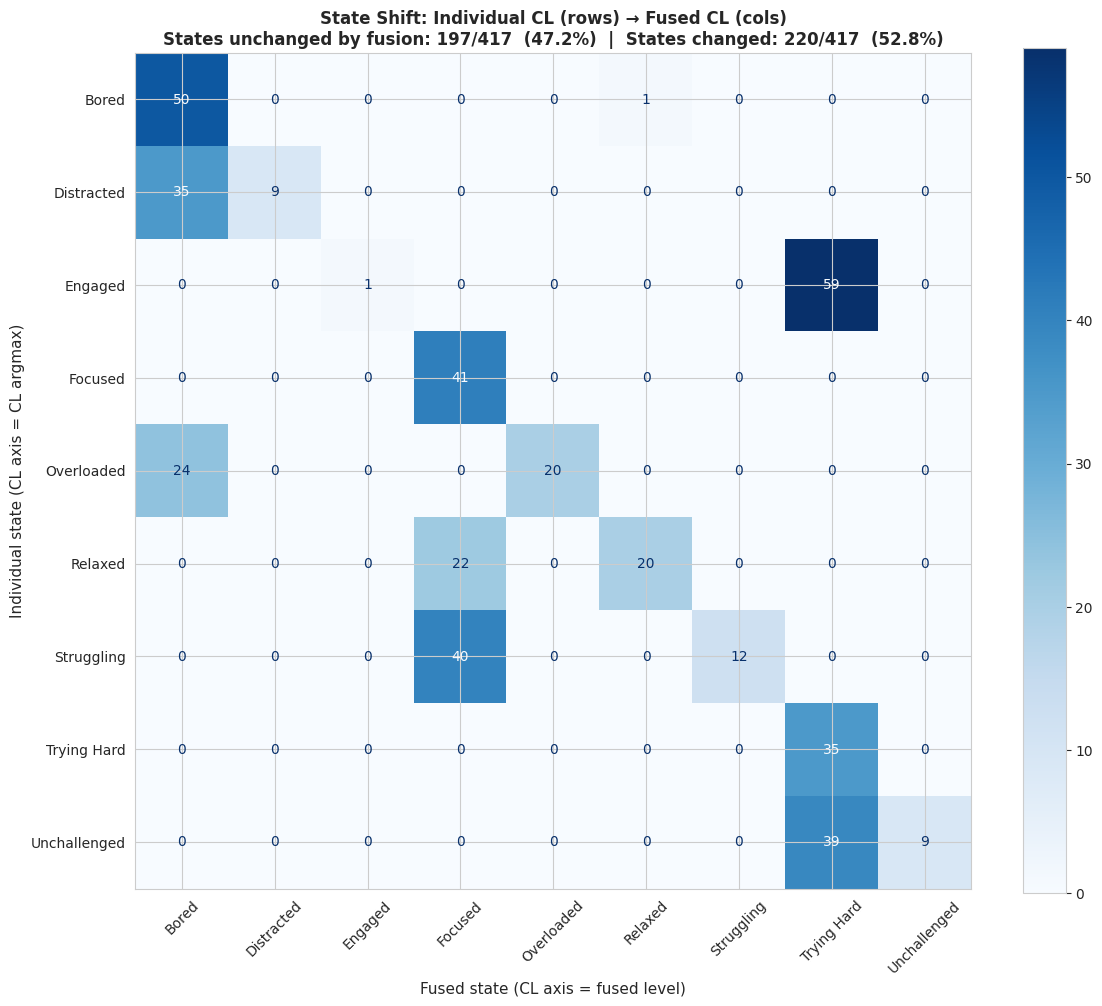

In [ ]:
# Plot the state shift matrix: rows = individual CL states, cols = fused states
# Encode state names as integers for the confusion matrix display
y_individual_enc = np.array([STATE_ENC[s] for s in cl_only_states])
y_fused_enc      = np.array([STATE_ENC[s] for s in fused_states])

# Diagonal cells are samples whose state did not change; off-diagonal cells show state shifts
fig, ax = plt.subplots(figsize=(12, 10))
cm_state = confusion_matrix(y_individual_enc, y_fused_enc,
                             labels=list(range(len(STATE_NAMES))))
ConfusionMatrixDisplay(cm_state, display_labels=STATE_NAMES).plot(
    ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45
)
ax.set_xlabel('Fused state (CL axis = fused level)', fontsize=11)
ax.set_ylabel('Individual state (CL axis = CL argmax)', fontsize=11)
ax.set_title(
    f'State Shift: Individual CL (rows) → Fused CL (cols)\n'
    f'States unchanged by fusion: {N_SAMPLES - state_changed}/{N_SAMPLES}  '
    f'({(1-state_changed/N_SAMPLES)*100:.1f}%)  |  '
    f'States changed: {state_changed}/{N_SAMPLES}  ({state_changed/N_SAMPLES*100:.1f}%)',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.savefig('/content/confusion_matrix_states.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.4 Fusion Weight Sensitivity Analysis

Sweep `W_CL` from 0.0 to 1.0 in steps of 0.05 and record Accuracy, Macro F1, and Cohen's Kappa at each value.
The weight that maximises Macro F1 is selected as the optimal operating point.
A stable plateau in the curve indicates the system is robust to small changes in the weight.

Optimal W_CL : 0.85  →  Acc=0.8897  F1=0.8917  Kappa=0.8341


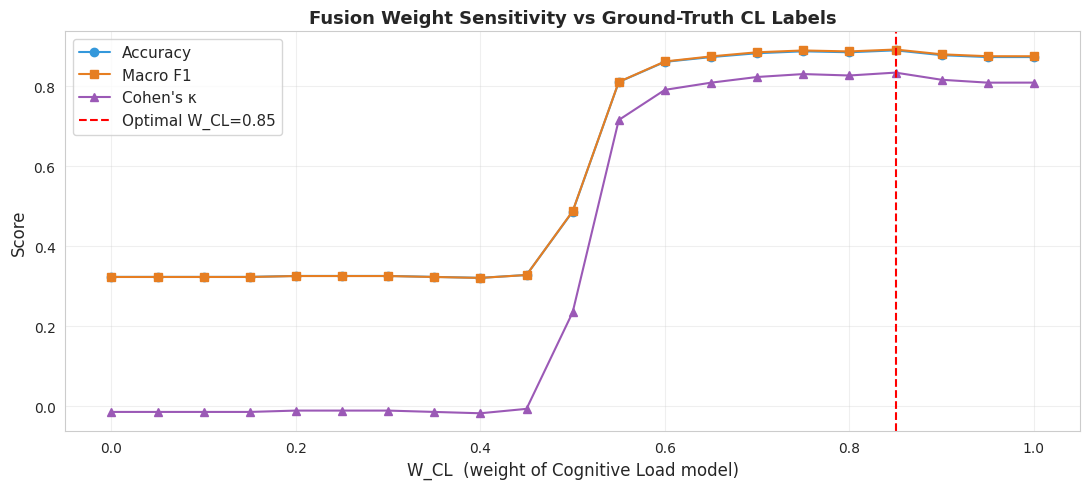

In [ ]:
# Sweep W_CL from 0.0 to 1.0 and record performance at each step
w_range     = np.linspace(0.0, 1.0, 21)
acc_sweep   = []
f1_sweep    = []
kappa_sweep = []

# At each weight value, run full fusion and record all three metrics
for w in w_range:
    yf, _, _, _, _, _ = predict_combined_state(
        prob_cl_aligned, prob_se_aligned, w_cl=w, w_se=1-w
    )
    acc_sweep.append(accuracy_score(y_true_cl, yf))
    f1_sweep.append(f1_score(y_true_cl, yf, average='macro', zero_division=0))
    kappa_sweep.append(cohen_kappa_score(y_true_cl, yf))

# Index of the weight that achieved the highest Macro F1
best_idx = int(np.argmax(f1_sweep))
best_w   = w_range[best_idx]
print(f'Optimal W_CL : {best_w:.2f}  →  '
      f'Acc={acc_sweep[best_idx]:.4f}  F1={f1_sweep[best_idx]:.4f}  Kappa={kappa_sweep[best_idx]:.4f}')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(w_range, acc_sweep,   'o-', label='Accuracy',   color='#3498db')
ax.plot(w_range, f1_sweep,    's-', label='Macro F1',   color='#e67e22')
ax.plot(w_range, kappa_sweep, '^-', label="Cohen's κ",  color='#9b59b6')
ax.axvline(best_w, color='red', linestyle='--', linewidth=1.5,
           label=f'Optimal W_CL={best_w:.2f}')
ax.set_xlabel('W_CL  (weight of Cognitive Load model)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Fusion Weight Sensitivity vs Ground-Truth CL Labels',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/weight_sensitivity.png', dpi=150)
plt.show()


### 5.5 Complete Evaluation Summary

In [ ]:
# Build a single summary table comparing all model configurations
summary = pd.DataFrame([
    {
# Each row is one model configuration; the table is sorted by Macro F1
        'Model':     f'{type(lr_cl).__name__} — Cognitive Load',
        'Accuracy':  round(acc_cl,    4),
        'Macro F1':  round(f1_cl,     4),
        'Kappa':     round(kappa_cl,  4),
        'vs':        'y_true_cl',
    },
    {
        'Model':     f'{type(xgb_se).__name__} — Student Engagement',
        'Accuracy':  round(acc_se,    4),
        'Macro F1':  round(f1_se,     4),
        'Kappa':     round(kappa_se,  4),
        'vs':        'y_true_se',
    },
    {
        'Model':     f'Late Fusion W_CL=0.5 / W_SE=0.5',
        'Accuracy':  round(acc_fused,   4),
        'Macro F1':  round(f1_fused,    4),
        'Kappa':     round(kappa_fused, 4),
        'vs':        'y_true_cl',
    },
    {
        'Model':     f'Late Fusion W_CL={best_w:.2f} (optimal)',
        'Accuracy':  round(acc_sweep[best_idx],   4),
        'Macro F1':  round(f1_sweep[best_idx],    4),
        'Kappa':     round(kappa_sweep[best_idx], 4),
        'vs':        'y_true_cl',
    },
])

print('=' * 72)
print('  COMPLETE EVALUATION SUMMARY  (N =', N_SAMPLES, ')')
print('=' * 72)
print(summary.to_string(index=False))
print('=' * 72)
summary


  COMPLETE EVALUATION SUMMARY  (N = 417 )
                              Model  Accuracy  Macro F1  Kappa        vs
LogisticRegression — Cognitive Load    0.8729    0.8749 0.8091 y_true_cl
           SVC — Student Engagement    0.9736    0.9732 0.9604 y_true_se
    Late Fusion W_CL=0.5 / W_SE=0.5    0.4868    0.4877 0.2352 y_true_cl
    Late Fusion W_CL=0.85 (optimal)    0.8897    0.8917 0.8341 y_true_cl


,Model,Accuracy,Macro F1,Kappa,vs
0,LogisticRegression — Cognitive Load,0.8729,0.8749,0.8091,y_true_cl
1,SVC — Student Engagement,0.9736,0.9732,0.9604,y_true_se
2,Late Fusion W_CL=0.5 / W_SE=0.5,0.4868,0.4877,0.2352,y_true_cl
3,Late Fusion W_CL=0.85 (optimal),0.8897,0.8917,0.8341,y_true_cl
